[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](
https://colab.research.google.com/github/mhuertascompany/euclid-school-2026/blob/main/Y1/notebooks/2-non_linear_regression.ipynb)

# Non linear regression

In this second example, we are going to complexify a bit the model, with two layers, one of 4 neurons, the other one of 1 neuron.

Note that it is still a bad idea to use deep learning for this... 

For this example, we're going to try predicting a bit more complex problem: predicting the distanc emodulus $\mu$ from the redshift z

In [1]:
import pandas as pd
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec


In [2]:
# from torchinfo import summary

Fixing the seeds for replicability

In [3]:
seed = 50

np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
torch.backends.cudnn.enabled = False

## Data
This time our data is real data, from the SH0ES experiment. We will try to predict the redshift of a source from it s distance modulus $\mu$

In [4]:
path = '.'

In [5]:
## If you are in google collab, uncomment this cell and run it:
## It will ask you to uplad a file, upload Pantheon_SH0ES.dat from the local data folder

# from google.colab import files
# uploaded = files.upload()
# path = '.'

In [6]:
df = pd.read_csv(
    "Pantheon_SH0ES.dat",
    sep=r"\s+"
)

z = np.expand_dims(df['zCMB'].values, 1)
mu = np.expand_dims(df['MU_SH0ES'].values, 1)

Text(0.5, 0, 'z')

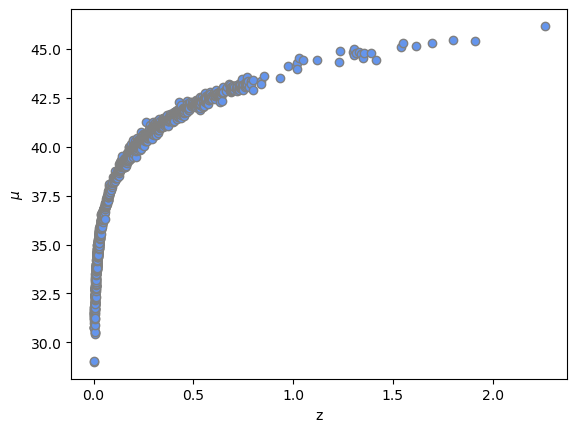

In [7]:
plt.scatter(z, mu, color='cornflowerblue', edgecolors='gray')
plt.ylabel(r'$\mu$')
plt.xlabel('z')

## Normalisation
Our data is more standardised than the previous example. No need of lo scale here, we are just going to take off the mean and divide by std.

Text(0.5, 0, 'z')

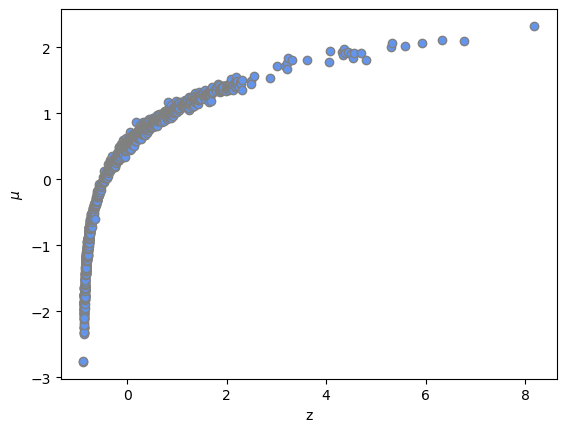

In [8]:
# standardization
norm_z = (z - np.mean(z)) /np.std(z)

norm_mu = (mu - np.mean(mu)) / np.std(mu)
plt.scatter(norm_z, norm_mu, color='cornflowerblue', edgecolors='gray')
plt.ylabel(r'$\mu$')
plt.xlabel('z')

## Data preparation
Here again, we transform our data to torch tensors, train and test splits, and batch them.
We need to add the feature dimension: for now our data is a scalar, but with the neurons we re going to learn features. So if our batch is (64,) (64 scalar), we need to transform it to (64, 1), 1 being the feature (just one dimension for now as the input is scalar. The layers will transforn this to e.g. (64, 32))

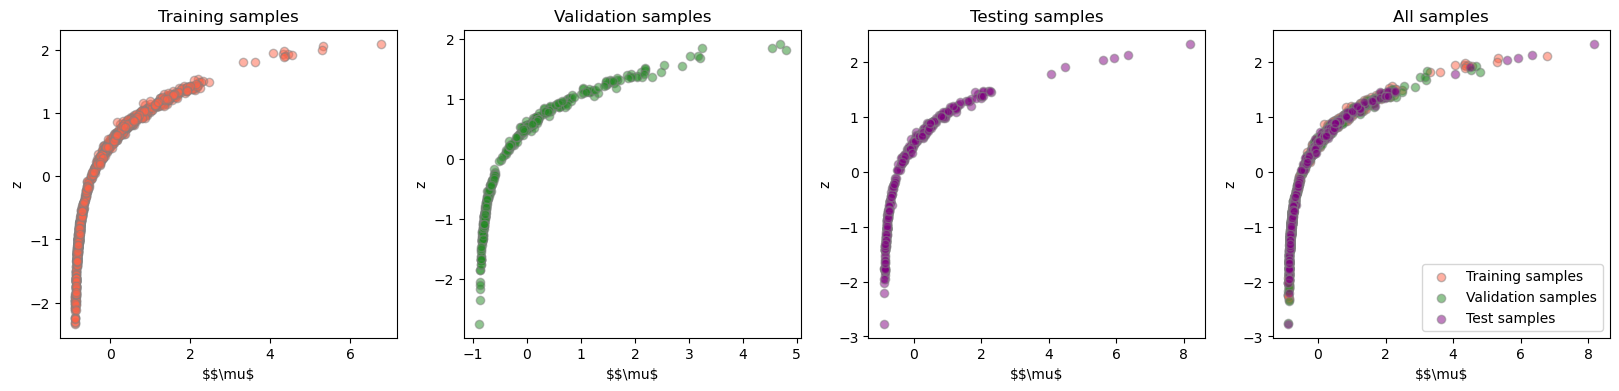

In [9]:

# set the number of samples per group
n_train_samples = int(0.6*len(norm_mu))
n_validation_samples = int(0.2*len(norm_mu))
n_test_samples = int(0.2*len(norm_mu))

# randomise your data for random reprentation in each group
random_samples_ids = np.arange(len(norm_mu))
np.random.shuffle(random_samples_ids)

# get the random ids
train_ids = random_samples_ids[:n_train_samples]
validation_ids = random_samples_ids[n_train_samples:n_train_samples+n_validation_samples]
test_ids = random_samples_ids[-n_test_samples:]

# create the sets
x_train = norm_z[train_ids]
y_train = norm_mu[train_ids]

x_validation = norm_z[validation_ids]
y_validation = norm_mu[validation_ids]

x_test = norm_z[test_ids]
y_test = norm_mu[test_ids]

fig, ax = plt.subplots(1, 4, figsize=(20, 4))
plt.subplots_adjust(wspace=0.2)

ax[0].scatter(x_train, y_train, c='tomato', alpha=0.5, edgecolors='gray', label='Training samples')
ax[1].scatter(x_validation, y_validation, c='forestgreen', alpha=0.5, edgecolors='gray', label='Validation samples')
ax[2].scatter(x_test, y_test, c='purple', alpha=0.5, edgecolors='gray', label='Test samples')

ax[3].scatter(x_train, y_train, c='tomato', alpha=0.5, edgecolors='gray', label='Training samples')
ax[3].scatter(x_validation, y_validation, c='forestgreen', alpha=0.5, edgecolors='gray', label='Validation samples')
ax[3].scatter(x_test, y_test, c='purple', alpha=0.5, edgecolors='gray', label='Test samples')
ax[3].legend()

ax[0].set_title('Training samples')
ax[1].set_title('Validation samples')
ax[2].set_title('Testing samples')
ax[3].set_title('All samples')
[axe.set_xlabel('$$\mu$') for axe in ax]
[axe.set_ylabel('z') for axe in ax];


In [10]:
x_train = torch.from_numpy(x_train).float()
y_train = torch.from_numpy(y_train).float()

x_validation = torch.from_numpy(x_validation).float()
y_validation = torch.from_numpy(y_validation).float()

x_test = torch.from_numpy(x_test).float()
y_test = torch.from_numpy(y_test).float()

In [11]:
print(f'train shape: {x_train.shape}')
print(f'validation shape: {x_validation.shape}')
print(f'test shape: {x_test.shape}')

train shape: torch.Size([1020, 1])
validation shape: torch.Size([340, 1])
test shape: torch.Size([340, 1])


## Model definition
We are going to use a slightly more complex model. 

We are still using neurons, but we are going to stack them vertically to create a layer: this is done by increasing the secind argument of the Linear function. While it still has one input (time), we create four neurons, which will each create a intermediate output d_i. 

We also add an activation to all our neuron, the ReLU taht we presented in the course. This make the model non linear, even if the neurons themselves are doing a linear operation (still wx + b for each, with a different w each)

We then stack a second layer, to create our final output. As we still want one output (estiamted mu), the final layer as only one neuron, but 4 inputs, the output of the first layer.


In [12]:

class SimpleNonlinearNN(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.model = torch.nn.Sequential(
            torch.nn.Linear(1, 4),   # First hidden layer
            # torch.nn.ReLU(),
            torch.nn.Linear(4, 1),    # Output layer
        )
    
    def forward(self, x):
        return self.model(x)

In [13]:
model_simple = SimpleNonlinearNN()
total_params = sum(p.numel() for p in model_simple.parameters())
print(f"Total parameters: {total_params}")

Total parameters: 13


In [15]:
# summary(model_simple, input_size=(32, 1))

### Optimisation
We still use a MSE loss, with stochastic gradient descent

In [16]:
criterion = torch.nn.MSELoss(size_average = False)
optimizer = torch.optim.SGD(model_simple.parameters(), lr = 0.001)

/opt/homebrew/Caskroom/miniconda/base/envs/euclid-school/lib/python3.11/site-packages/torch/nn/_reduction.py:51: UserWarning: size_average and reduce args will be deprecated, please use reduction='sum' instead.
  warnings.warn(warning.format(ret))


# Training
The training model is the exact same as before. Our model is just more complex

In [17]:
batch_size = 128
n_epochs = 70

In [18]:
def train_model(model, batch_size, optimizer):
    losses_steps = []
    losses_epochs = []
    val_losses = []
    for epoch in range(n_epochs):
        loss_epoch = 0

        #shuffle the trainig data each epoch for better stochasticity
        indices = torch.randperm(n_train_samples)
        x_shuffled = x_train[indices]
        y_shuffled = y_train[indices]

        # loop through the dataset per batch
        model.train()
        for i, start_idx in enumerate(range(0, n_train_samples, batch_size)):
            
            # take only the current batch
            end_idx = start_idx + batch_size
            x_batch = x_shuffled[start_idx:end_idx]
            y_batch = y_shuffled[start_idx:end_idx]

            # use the model to predict on the batch
            pred_y = model(x_batch)

            # Compute the loss on the batch and log it
            loss = criterion(pred_y, y_batch)
            loss_epoch += loss.detach().numpy()
            losses_steps.append(loss.detach().numpy())

            # Zero gradients (not accumulate)
            optimizer.zero_grad()
            
            # compute the gradients
            loss.backward()

            # apply the gradients to optimise
            optimizer.step()
        
        model.eval()
        pred_val_y = model(x_validation)
        val_loss = criterion(pred_val_y, y_validation)
        val_losses.append(val_loss.detach().numpy())
        # Compute the mean loss on the epoch
        losses_epochs.append(loss_epoch / i)

    return losses_epochs, losses_steps, val_losses


In [19]:
losses_epochs, losses_steps, val_losses = train_model(model_simple, batch_size, optimizer)

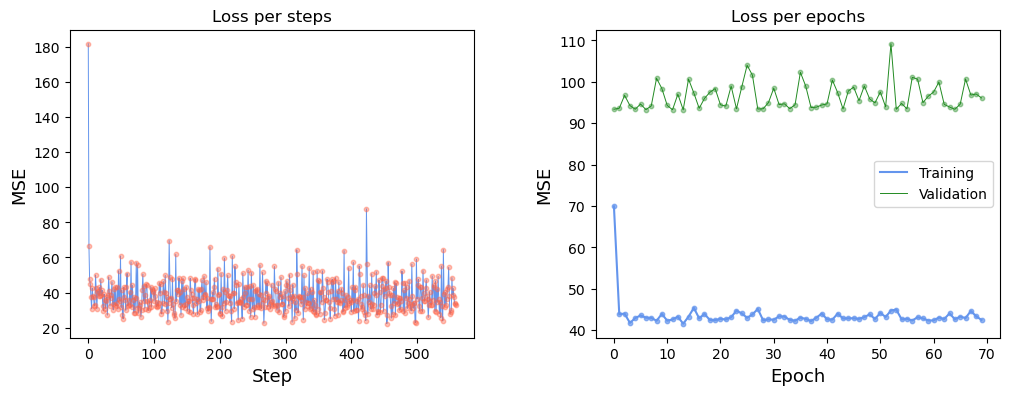

In [20]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
plt.subplots_adjust(wspace=0.3)
ax[0].scatter(np.arange(len(losses_steps)), losses_steps, alpha=0.4, s=10, c='tomato', zorder=5)
ax[0].plot(np.arange(len(losses_steps)), losses_steps, c='cornflowerblue', lw=.7)

ax[1].scatter(np.arange(len(losses_epochs)), losses_epochs, alpha=0.7, s=10, c='cornflowerblue', zorder=5)
ax[1].plot(np.arange(len(losses_epochs)), losses_epochs, c='cornflowerblue', label='Training')
ax[1].scatter(np.arange(len(losses_epochs)), val_losses, alpha=0.4, s=10, c='forestgreen', zorder=5)
ax[1].plot(np.arange(len(losses_epochs)), val_losses, c='forestgreen', lw=.7, label='Validation')


[axe.set_ylabel('MSE', fontsize=13) for axe in ax]
ax[0].set_xlabel('Step', fontsize=13)
ax[1].set_xlabel('Epoch', fontsize=13)

ax[0].set_title('Loss per steps')
ax[1].set_title('Loss per epochs')
ax[1].legend();

Our model is learning!

# Testing

We can now show what our train mode does, both in the training set and testing set:

In [21]:
model_simple.eval()
pred_on_train = model_simple(x_train)
pred_on_test = model_simple(x_test)

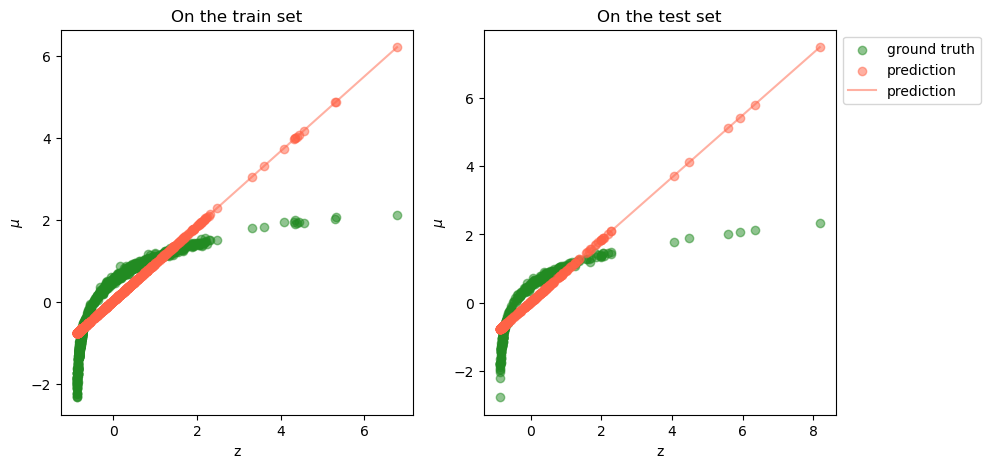

In [22]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
train_sort = np.argsort(x_train.detach().numpy()[:, 0])
ax[0].scatter(x_train, y_train, color='forestgreen', alpha=0.5, label='ground truth')
ax[0].scatter(x_train, pred_on_train.detach().numpy(), color='tomato', alpha=0.5, label='prediction')
ax[0].plot(x_train[train_sort], pred_on_train.detach().numpy()[train_sort], color='tomato', alpha=0.5, label='prediction')

test_sort = np.argsort(x_test.detach().numpy()[:, 0])
ax[1].scatter(x_test, y_test, color='forestgreen', alpha=0.5, label='ground truth')
ax[1].scatter(x_test, pred_on_test.detach().numpy(), color='tomato', alpha=0.5, label='prediction')
ax[1].plot(x_test[test_sort], pred_on_test.detach().numpy()[test_sort], color='tomato', alpha=0.5, label='prediction')

ax[1].legend(bbox_to_anchor=(1, 1), loc='upper left')

[axe.set_ylabel(r'$\mu$') for axe in ax]
[axe.set_xlabel('z') for axe in ax]

ax[0].set_title('On the train set')
ax[1].set_title('On the test set');


We see that we are now non linear!

## play with the model

- Try to remove the activation (ReLU), see what happens!
- Add a ReLU after the last layer, what happens?